In [2]:
import duckdb
con = duckdb.connect("../fundos_cvm.duckdb")

con.execute("""
    SELECT
        cnpj_classe,
        denominacao_social,
        classificacao_anbima,
        patrimonio_liquido
    FROM classe
    WHERE classificacao_anbima = 'Multimercados Livre'
      AND situacao = 'Em Funcionamento Normal'
      AND patrimonio_liquido > 500000000
    ORDER BY patrimonio_liquido DESC
""").fetchdf()

,cnpj_classe,denominacao_social,classificacao_anbima,patrimonio_liquido
0,58.020.336/0001-04,NAUATLE FUNDO DE INVESTIMENTO FINANCEIRO MULTI...,Multimercados Livre,2.690000e+10
1,32.033.283/0001-64,OLAF 95 FUNDO DE INVESTIMENTO FINANCEIRO MULTI...,Multimercados Livre,2.662180e+10
2,34.791.568/0001-90,FP ESTRATÉGIA FI FINANCEIRO - CI MULT - RESP L...,Multimercados Livre,1.524956e+10
3,01.912.197/0001-06,FPRV1 SABIÁ FUNDO DE INVESTIMENTO FINANCEIRO M...,Multimercados Livre,1.407115e+10
4,29.389.028/0001-44,CAIXA FG-FIES FUNDO DE INVESTIMENTO FINANCEIRO...,Multimercados Livre,1.301025e+10
...,...,...,...,...
368,45.081.614/0001-83,BB MULTIGESTOR MÓDULO CRÉDITO PRIVADO FUNDO DE...,Multimercados Livre,5.034762e+08
369,30.453.289/0001-65,G5 ALLOCATION FUNDO DE INVESTIMENTO FINANCEIRO...,Multimercados Livre,5.033199e+08
370,60.715.887/0001-26,PCS II PPE FEEDER BRASIL FUNDO DE INVESTIMENTO...,Multimercados Livre,5.020280e+08
371,04.052.631/0001-05,MULTIPREV CARTEIRA 4 FUNDO DE INVESTIMENTO FIN...,Multimercados Livre,5.012875e+08


In [4]:
con.execute("""
    SELECT
        classificacao_anbima,
        COUNT(*)                     AS qtd_classes,
        SUM(patrimonio_liquido)      AS patrimonio_total,
        AVG(patrimonio_liquido)      AS patrimonio_medio,
        MIN(patrimonio_liquido)      AS patrimonio_min,
        MAX(patrimonio_liquido)      AS patrimonio_max
    FROM classe
    WHERE situacao = 'Em Funcionamento Normal'
    GROUP BY classificacao_anbima
    ORDER BY patrimonio_total DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,patrimonio_total,patrimonio_medio,patrimonio_min,patrimonio_max
0,None,8130,2.755776e+12,3.607037e+08,-2.341404e+08,2.299781e+11
1,Renda Fixa Duração Baixa Grau de Invest.,503,1.734334e+12,3.447980e+09,0.000000e+00,1.363835e+11
2,Renda Fixa Duração Baixa Soberano,250,1.259624e+12,5.038496e+09,-3.784108e+04,2.036694e+11
3,Renda Fixa Duração Livre Crédito Livre,3051,1.112488e+12,3.660706e+08,-1.736404e+07,2.951603e+10
4,Renda Fixa Duração Livre Grau de Invest.,886,1.102803e+12,1.246105e+09,0.000000e+00,9.746824e+10
...,...,...,...,...,...,...
61,Previdência Balanceados acima de 49,18,6.211833e+08,3.451018e+07,1.627140e+06,1.228800e+08
62,Renda Fixa Dívida Externa,4,3.892475e+07,9.731187e+06,4.360110e+06,2.095799e+07
63,FII Hibrido Gestão Ativa,1,2.930892e+07,2.930892e+07,2.930892e+07,2.930892e+07
64,FIDC Outros,1,1.392219e+07,1.392219e+07,1.392219e+07,1.392219e+07


In [5]:
con.execute("""
    SELECT tipo_classe, COUNT(*) AS qtd
    FROM classe
    WHERE situacao = 'Em Funcionamento Normal'
      AND classificacao_anbima IS NULL
    GROUP BY tipo_classe
    ORDER BY qtd DESC
""").fetchdf()

,tipo_classe,qtd
0,Classes de Cotas de Fundos FIDC,4112
1,Classes de Cotas de Fundos FIP,2111
2,Classes de Cotas de Fundos FII,1287
3,Classes de Cotas de Fundos FIAGRO,272
4,Classes de Cotas de Fundos FIIM,202
5,Classes de Cotas de Fundos FIF,129
6,Classes de Cotas de Fundos FIF (FAPI),13
7,Classes de Cotas de Fundos Funcine,4


In [6]:
con.execute("""
    SELECT
        classificacao_anbima,
        COUNT(*)                     AS qtd_classes,
        SUM(patrimonio_liquido)      AS patrimonio_total,
        AVG(patrimonio_liquido)      AS patrimonio_medio,
        MIN(patrimonio_liquido)      AS patrimonio_min,
        MAX(patrimonio_liquido)      AS patrimonio_max
    FROM classe
    WHERE situacao = 'Em Funcionamento Normal'
      AND tipo_classe = 'Classes de Cotas de Fundos FIF'
      AND classificacao_anbima IS NOT NULL
    GROUP BY classificacao_anbima
    ORDER BY patrimonio_total DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,patrimonio_total,patrimonio_medio,patrimonio_min,patrimonio_max
0,Renda Fixa Duração Baixa Grau de Invest.,503,1.734334e+12,3.447980e+09,0.000000e+00,1.363835e+11
1,Renda Fixa Duração Baixa Soberano,250,1.259624e+12,5.038496e+09,-3.784108e+04,2.036694e+11
2,Renda Fixa Duração Livre Crédito Livre,3051,1.112488e+12,3.660706e+08,-1.736404e+07,2.951603e+10
3,Renda Fixa Duração Livre Grau de Invest.,886,1.102803e+12,1.246105e+09,0.000000e+00,9.746824e+10
4,Multimercados Livre,4063,9.632236e+11,2.385398e+08,-1.416329e+08,2.690000e+10
...,...,...,...,...,...,...
60,Previdência Balanceados acima de 49,18,6.211833e+08,3.451018e+07,1.627140e+06,1.228800e+08
61,Renda Fixa Dívida Externa,4,3.892475e+07,9.731187e+06,4.360110e+06,2.095799e+07
62,FII Hibrido Gestão Ativa,1,2.930892e+07,2.930892e+07,2.930892e+07,2.930892e+07
63,FIDC Outros,1,1.392219e+07,1.392219e+07,1.392219e+07,1.392219e+07


In [7]:
con.execute("""
    SELECT
        classificacao_anbima,
        COUNT(*) AS qtd_classes,
        SUM(patrimonio_liquido) AS patrimonio_total
    FROM classe
    WHERE situacao = 'Em Funcionamento Normal'
      AND tipo_classe = 'Classes de Cotas de Fundos FIF'
      AND classificacao_anbima IS NOT NULL
    GROUP BY classificacao_anbima
    HAVING COUNT(*) >= 100
    ORDER BY patrimonio_total DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,patrimonio_total
0,Renda Fixa Duração Baixa Grau de Invest.,503,1.734334e+12
1,Renda Fixa Duração Baixa Soberano,250,1.259624e+12
2,Renda Fixa Duração Livre Crédito Livre,3051,1.112488e+12
3,Renda Fixa Duração Livre Grau de Invest.,886,1.102803e+12
4,Multimercados Livre,4063,9.632236e+11
5,Previdência RF Duração Baixa Grau de Inv,119,9.369985e+11
6,Multimercados Invest. no Exterior,5218,8.775327e+11
7,Previdência RF Duração Livre Grau de Inv,352,6.563009e+11
8,Previdência Multimercado Livre,2546,6.329316e+11
9,Renda Fixa Simples,169,4.728720e+11


In [8]:
con.execute("""
    SELECT
        a.nome AS administrador,
        COUNT(DISTINCT c.id_registro_classe) AS qtd_classes
    FROM classe c
    JOIN fundo f
        ON c.id_registro_fundo = f.id_registro_fundo
    JOIN administrador a
        ON f.cnpj_administrador = a.cnpj_administrador
    WHERE c.situacao = 'Em Funcionamento Normal'
    GROUP BY a.nome
    ORDER BY qtd_classes DESC
    LIMIT 15
""").fetchdf()

,administrador,qtd_classes
0,BTG PACTUAL SERVIÇOS FINANCEIROS S/A DTVM,6811
1,ITAU UNIBANCO S.A.,3226
2,BEM - DISTRIBUIDORA DE TITULOS E VALORES MOBIL...,2496
3,INTRAG DTVM LTDA.,2289
4,BNY MELLON SERVICOS FINANCEIROS DTVM S.A.,1786
5,BANCO BRADESCO S.A.,1731
6,BB GESTAO DE RECURSOS DTVM S.A,1286
7,XP INVESTIMENTOS CCTVM S.A.,1048
8,SANTANDER DISTRIBUIDORA DE TÍTULOS E VALORES M...,1009
9,SAFRA ASSET CORRETORA DE TÍTULOS E VALORES MOB...,970


In [14]:
#valores de vl_quota próximos de zero?

con.execute("""
    SELECT
        cnpj_classe, id_subclasse, dt_comptc, vl_quota
    FROM informe_diario
    WHERE vl_quota > 0
    ORDER BY vl_quota ASC
    LIMIT 10
""").fetchdf()

,cnpj_classe,id_subclasse,dt_comptc,vl_quota
0,53.306.332/0001-65,,2025-02-17,1.000000e-08
1,53.306.332/0001-65,,2025-02-27,1.000000e-08
2,53.306.332/0001-65,,2025-02-25,1.000000e-08
3,53.306.332/0001-65,,2025-01-28,1.000000e-08
4,53.306.332/0001-65,,2025-02-24,1.000000e-08
5,53.306.332/0001-65,,2025-01-14,1.000000e-08
6,53.306.332/0001-65,,2025-01-30,1.000000e-08
7,53.306.332/0001-65,,2025-02-26,1.000000e-08
8,53.306.332/0001-65,,2025-01-31,1.000000e-08
9,53.306.332/0001-65,,2025-01-22,1.000000e-08


In [15]:
# investigar o fundo com vl_quota extremamente baixo

con.execute("""
    SELECT
        i.dt_comptc, i.vl_quota, i.vl_patrim_liq, i.vl_total, i.nr_cotst,
        c.denominacao_social, c.classificacao_anbima, c.situacao
    FROM informe_diario i
    JOIN classe c ON i.cnpj_classe = c.cnpj_classe
    WHERE i.cnpj_classe = '53.306.332/0001-65'
    ORDER BY i.dt_comptc
""").fetchdf()

,dt_comptc,vl_quota,vl_patrim_liq,vl_total,nr_cotst,denominacao_social,classificacao_anbima,situacao
0,2025-01-02,1.000000e-08,1.000000e-02,1.144155e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
1,2025-01-03,2.000000e-08,1.000000e-02,1.174716e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
2,2025-01-06,1.000000e-08,1.000000e-02,1.229727e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
3,2025-01-07,1.000000e-08,1.000000e-02,1.254176e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
4,2025-01-08,1.000000e-08,1.000000e-02,1.193055e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
...,...,...,...,...,...,...,...,...
247,2025-12-24,5.111569e+02,2.725298e+08,2.665784e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
248,2025-12-26,5.386706e+02,2.871991e+08,2.812477e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
249,2025-12-29,5.100106e+02,2.719186e+08,2.659673e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal
250,2025-12-30,5.317923e+02,2.835318e+08,2.775805e+08,1,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,Fechados de Ações,Em Funcionamento Normal


In [16]:
# fundos que têm nr_cotst = 1
# avaliar se o caso do Genoma PG é isolado ou padrão

con.execute("""
    SELECT COUNT(DISTINCT cnpj_classe) AS qtd_fundos_exclusivos
    FROM informe_diario
    WHERE nr_cotst = 1
""").fetchdf()

,qtd_fundos_exclusivos
0,11746


In [17]:
# quantas classes têm valor de cota extremamente baixo

con.execute("""
    SELECT COUNT(DISTINCT cnpj_classe) AS qtd_classes_quota_baixa
    FROM informe_diario
    WHERE vl_quota > 0 AND vl_quota < 0.01
""").fetchdf()

,qtd_classes_quota_baixa
0,20


In [18]:
# pergunta 1: Como evoluiu o valor da cota por classificação ANBIMA ao longo de 2025?

con.execute("""
    WITH classes_validas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota > 0 AND vl_quota < 0.01
    ),
    cota_extremos AS (
        SELECT DISTINCT
            i.cnpj_classe,
            i.id_subclasse,
            c.classificacao_anbima,
            FIRST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) AS quota_inicial,
            LAST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
                RANGE BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            ) AS quota_final
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
          AND c.classificacao_anbima IS NOT NULL
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_validas)
    )
    SELECT
        classificacao_anbima,
        COUNT(*) AS qtd_classes,
        ROUND(AVG((quota_final / quota_inicial - 1) * 100), 2) AS retorno_medio_pct
    FROM cota_extremos
    WHERE quota_inicial > 0
    GROUP BY classificacao_anbima
    HAVING COUNT(*) >= 100
    ORDER BY retorno_medio_pct DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,retorno_medio_pct
0,Multimercados Livre,3942,101.44
1,Ações Valor/Crescimento,104,20.69
2,Ações Invest. no Exterior,1099,20.53
3,Ações Índice Ativo,194,20.28
4,Previdência Ações Ativo,281,17.48
5,Fechados de Ações,131,14.38
6,Multimercados Dinâmico,181,13.92
7,Multimercados L/S - Direcional,110,13.18
8,Renda Fixa Duração Média Grau de Invest.,125,11.12
9,Previdência Multimercado Livre,2498,10.56


In [19]:
# quais classes específicas estão distorcendo Multimercados Livre e Ações Livre
# (mesmo após excluir o filtro de cota baixíssima)

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota > 0 AND vl_quota < 0.01
    ),
    cota_extremos AS (
        SELECT DISTINCT
            i.cnpj_classe,
            c.denominacao_social,
            c.classificacao_anbima,
            FIRST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) AS quota_inicial,
            LAST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
                RANGE BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            ) AS quota_final
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.classificacao_anbima IN ('Multimercados Livre', 'Ações Livre')
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT *,
        ROUND((quota_final / quota_inicial - 1) * 100, 2) AS retorno_pct
    FROM cota_extremos
    WHERE quota_inicial > 0
    ORDER BY ABS(retorno_pct) DESC
    LIMIT 10
""").fetchdf()

,cnpj_classe,denominacao_social,classificacao_anbima,quota_inicial,quota_final,retorno_pct
0,53.755.078/0001-82,SERENA I - FUNDO DE INVESTIMENTO FINANCEIRO EM...,Ações Livre,557.501333,-2.165812e+07,-3884955.23
1,61.866.056/0001-18,CLASSE ÚNICA DE COTAS DO EVOLUTION MULTISTRATE...,Multimercados Livre,1000.000000,2.264535e+06,226353.53
2,59.076.923/0001-70,SAGEL ASSESSORIA E PARTICIPAÇÕES FIC FIM CLASSE,Multimercados Livre,1.000000,1.158063e+03,115706.30
3,09.555.452/0001-04,GAMA FI FINANCEIRO - CI MULT CRED PRIV - RESP ...,Multimercados Livre,866.369563,4.015941e+04,4535.37
4,61.603.679/0001-06,NOVA EDGE CAPITAL FUNDO DE INVESTIMENTO FINANC...,Multimercados Livre,1000.000000,4.464574e+04,4364.57
5,55.711.544/0001-53,ETT - FUNDO DE INVESTIMENTO FINANCEIRO MULTIME...,Multimercados Livre,78.201797,2.438864e+03,3018.68
6,60.600.091/0001-28,EROS II FUNDO DE INVESTIMENTO FINANCEIRO MULTI...,Multimercados Livre,991.863500,2.293496e+04,2212.31
7,58.614.804/0001-60,POLYNESIA FUNDO DE INVESTIMENTO MULTIMERCADO C...,Multimercados Livre,1000.000000,1.747575e+04,1647.57
8,34.706.401/0001-83,XLI FUNDO DE INVESTIMENTO FINANCEIRO MULTIMERCADO,Multimercados Livre,0.119704,2.063206e+00,1623.58
9,53.819.383/0001-90,FPMFP FUNDO DE INVESTIMENTO MULTIMERCADO CRÉDI...,Multimercados Livre,2582.035437,4.139427e+04,1503.16


In [20]:
#  exclui classes que tiveram cota negativa

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    cota_extremos AS (
        SELECT DISTINCT
            i.cnpj_classe,
            i.id_subclasse,
            c.classificacao_anbima,
            FIRST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) AS quota_inicial,
            LAST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
                RANGE BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            ) AS quota_final
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
          AND c.classificacao_anbima IS NOT NULL
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT
        classificacao_anbima,
        COUNT(*) AS qtd_classes,
        ROUND(AVG((quota_final / quota_inicial - 1) * 100), 2) AS retorno_medio_pct
    FROM cota_extremos
    WHERE quota_inicial > 0
    GROUP BY classificacao_anbima
    HAVING COUNT(*) >= 100
    ORDER BY retorno_medio_pct DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,retorno_medio_pct
0,Multimercados Livre,3869,102.73
1,Ações Valor/Crescimento,104,20.69
2,Ações Invest. no Exterior,1099,20.53
3,Ações Índice Ativo,194,20.28
4,Ações Livre,2016,19.39
5,Previdência Ações Ativo,281,17.48
6,Fechados de Ações,131,14.38
7,Multimercados L/S - Direcional,110,13.18
8,Renda Fixa Duração Média Grau de Invest.,124,11.15
9,Previdência Multimercado Livre,2494,10.56


In [21]:
# quais classes específicas de Multimercados Livre ainda têm

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    cota_extremos AS (
        SELECT DISTINCT
            i.cnpj_classe,
            c.denominacao_social,
            FIRST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) AS quota_inicial,
            LAST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
                RANGE BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            ) AS quota_final
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.classificacao_anbima = 'Multimercados Livre'
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT *,
        ROUND((quota_final / quota_inicial - 1) * 100, 2) AS retorno_pct
    FROM cota_extremos
    WHERE quota_inicial > 0
    ORDER BY retorno_pct DESC
    LIMIT 10
""").fetchdf()

,cnpj_classe,denominacao_social,quota_inicial,quota_final,retorno_pct
0,61.866.056/0001-18,CLASSE ÚNICA DE COTAS DO EVOLUTION MULTISTRATE...,1000.000000,2.264535e+06,226353.53
1,59.076.923/0001-70,SAGEL ASSESSORIA E PARTICIPAÇÕES FIC FIM CLASSE,1.000000,1.158063e+03,115706.30
2,09.555.452/0001-04,GAMA FI FINANCEIRO - CI MULT CRED PRIV - RESP ...,866.369563,4.015941e+04,4535.37
3,61.603.679/0001-06,NOVA EDGE CAPITAL FUNDO DE INVESTIMENTO FINANC...,1000.000000,4.464574e+04,4364.57
4,55.711.544/0001-53,ETT - FUNDO DE INVESTIMENTO FINANCEIRO MULTIME...,78.201797,2.438864e+03,3018.68
5,60.600.091/0001-28,EROS II FUNDO DE INVESTIMENTO FINANCEIRO MULTI...,991.863500,2.293496e+04,2212.31
6,34.706.401/0001-83,XLI FUNDO DE INVESTIMENTO FINANCEIRO MULTIMERCADO,0.119704,2.063206e+00,1623.58
7,53.819.383/0001-90,FPMFP FUNDO DE INVESTIMENTO MULTIMERCADO CRÉDI...,2582.035437,4.139427e+04,1503.16
8,53.453.313/0001-61,LVC FUNDO DE INVESTIMENTO EM COTAS DE FI MULTI...,892.913097,4.621508e+03,417.58
9,57.191.768/0001-07,JGP MALLS I FUNDO DE INVESTIMENTO FINANCEIRO M...,1.000000,4.369464e+00,336.95


In [22]:
# Pergunta 1: retorno por classificação ANBIMA usando MEDIANA

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    cota_extremos AS (
        SELECT DISTINCT
            i.cnpj_classe,
            i.id_subclasse,
            c.classificacao_anbima,
            FIRST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) AS quota_inicial,
            LAST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
                RANGE BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            ) AS quota_final
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
          AND c.classificacao_anbima IS NOT NULL
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT
        classificacao_anbima,
        COUNT(*) AS qtd_classes,
        ROUND(MEDIAN((quota_final / quota_inicial - 1) * 100), 2) AS retorno_mediano_pct,
        ROUND(AVG((quota_final / quota_inicial - 1) * 100), 2)    AS retorno_medio_pct
    FROM cota_extremos
    WHERE quota_inicial > 0
    GROUP BY classificacao_anbima
    HAVING COUNT(*) >= 100
    ORDER BY retorno_mediano_pct DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,retorno_mediano_pct,retorno_medio_pct
0,Ações Valor/Crescimento,104,20.43,20.69
1,Ações Invest. no Exterior,1099,18.17,20.53
2,Ações Índice Ativo,194,17.58,20.28
3,Ações Livre,2016,16.91,19.39
4,Previdência Ações Ativo,281,15.64,17.48
5,Fechados de Ações,131,14.69,14.38
6,Renda Fixa Duração Média Grau de Invest.,124,12.15,11.15
7,Multimercados L/S - Direcional,110,11.25,13.18
8,Renda Fixa Simples,168,10.62,9.60
9,Renda Fixa Duração Baixa Grau de Invest.,501,10.62,10.31


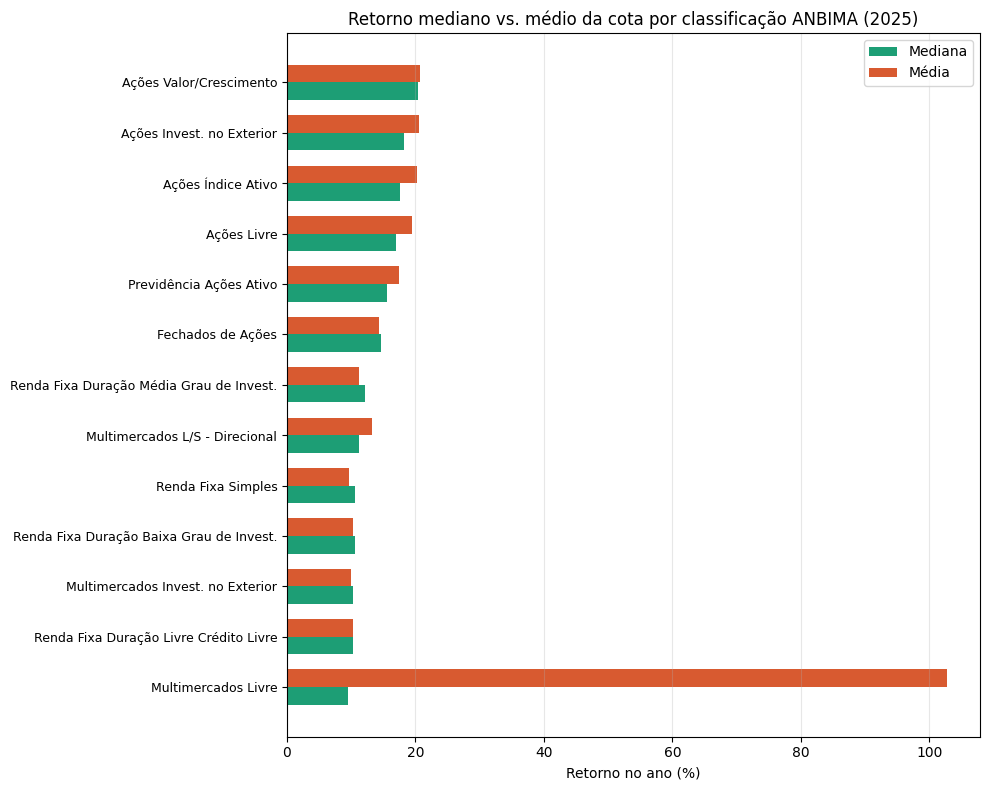

In [26]:
# retorno mediano vs. médio da cota por classificação ANBIMA em 2025

import matplotlib.pyplot as plt
import pandas as pd

df_p1 = con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    cota_extremos AS (
        SELECT DISTINCT
            i.cnpj_classe,
            i.id_subclasse,
            c.classificacao_anbima,
            FIRST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) AS quota_inicial,
            LAST_VALUE(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
                RANGE BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            ) AS quota_final
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
          AND c.classificacao_anbima IS NOT NULL
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    ),
    agregado AS (
        SELECT
            classificacao_anbima,
            COUNT(*) AS qtd_classes,
            ROUND(MEDIAN((quota_final / quota_inicial - 1) * 100), 2) AS retorno_mediano_pct,
            ROUND(AVG((quota_final / quota_inicial - 1) * 100), 2)    AS retorno_medio_pct
        FROM cota_extremos
        WHERE quota_inicial > 0
        GROUP BY classificacao_anbima
        HAVING COUNT(*) >= 100
    )
    SELECT *,
        ABS(retorno_medio_pct - retorno_mediano_pct) AS contraste
    FROM agregado
    ORDER BY retorno_mediano_pct DESC
""").fetchdf()

# Destaca as top 12 por mediana + garante que Multimercados Livre apareça
top_mediana = df_p1.head(12)
destaque = df_p1[df_p1['classificacao_anbima'] == 'Multimercados Livre']
df_plot = pd.concat([top_mediana, destaque]).drop_duplicates(subset='classificacao_anbima')
df_plot = df_plot.sort_values('retorno_mediano_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(df_plot))
bar_height = 0.35

ax.barh([y + bar_height/2 for y in y_pos], df_plot['retorno_mediano_pct'],
        height=bar_height, label='Mediana', color='#1D9E75')
ax.barh([y - bar_height/2 for y in y_pos], df_plot['retorno_medio_pct'],
        height=bar_height, label='Média', color='#D85A30')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['classificacao_anbima'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Retorno no ano (%)')
ax.set_title('Retorno mediano vs. médio da cota por classificação ANBIMA (2025)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/grafico_p1_retorno_classificacao.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# pergunta 2a: auais classes tiveram maior captação líquida em 2025?

con.execute("""
    SELECT
        i.cnpj_classe,
        c.denominacao_social,
        c.classificacao_anbima,
        SUM(i.captc_dia)              AS captacao_total,
        SUM(i.resg_dia)               AS resgate_total,
        SUM(i.captc_dia - i.resg_dia) AS captacao_liquida
    FROM informe_diario i
    JOIN classe c ON i.cnpj_classe = c.cnpj_classe
    WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
    GROUP BY i.cnpj_classe, c.denominacao_social, c.classificacao_anbima
    ORDER BY captacao_liquida DESC
    LIMIT 15
""").fetchdf()

,cnpj_classe,denominacao_social,classificacao_anbima,captacao_total,resgate_total,captacao_liquida
0,60.491.442/0001-00,ITAÚBA FUNDO INCENTIVADO DE INVESTIMENTO FINAN...,Renda Fixa Duração Livre Crédito Livre,3.154845e+10,6.568756e+08,3.089158e+10
1,51.998.694/0001-39,ITAÚ CRÉDITO BANCÁRIO RENDA FIXA CRÉDITO PRIVA...,Renda Fixa Duração Média Grau de Invest.,3.605316e+10,2.108885e+10,1.496431e+10
2,29.224.634/0001-00,BB RENDA FIXA LONGO PRAZO HIGH FUNDO DE INVEST...,Renda Fixa Duração Livre Grau de Invest.,5.025975e+10,3.538516e+10,1.487459e+10
3,03.504.023/0001-21,BB TOP PRINCIPAL RENDA FIXA REFERENCIADO DI LO...,Renda Fixa Duração Baixa Soberano,8.618609e+10,7.141023e+10,1.477586e+10
4,56.915.560/0001-20,ITAÚ CRÉDITO BANCÁRIO RENDA FIXA CRÉDITO PRIVA...,Renda Fixa Duração Média Grau de Invest.,1.555992e+10,9.926233e+08,1.456729e+10
5,46.133.770/0001-03,BB TOP RENDA FIXA CURTO PRAZO AUTOMÁTICO II FU...,Renda Fixa Duração Baixa Soberano,8.485504e+11,8.347583e+11,1.379216e+10
6,54.487.736/0001-65,SANTANDER HERA RENDA FIXA FUNDO INCENTIVADO DE...,Renda Fixa Duração Livre Crédito Livre,1.199624e+10,0.000000e+00,1.199624e+10
7,44.703.501/0001-00,BRADESCO ULTRA PGBLVGBL FI FINANCEIRO - CIC RF...,Previdência RF Duração Livre Crédito Liv,1.334136e+10,1.818169e+09,1.152319e+10
8,44.703.508/0001-21,BRADESCO ULTRA PREVIDÊNCIA FIE II FI FINANCEIR...,Previdência RF Duração Livre Crédito Liv,1.334518e+10,1.823750e+09,1.152143e+10
9,58.824.505/0001-50,SANTANDER SBAC II RENDA FIXA CURTO PRAZO - FUN...,Renda Fixa Duração Baixa Soberano,5.721460e+10,4.582449e+10,1.139011e+10


In [28]:
# pergunta 2b: há sazonalidade no fluxo de captação/resgate ao longo do ano?

con.execute("""
    SELECT
        EXTRACT(MONTH FROM i.dt_comptc) AS mes,
        SUM(i.captc_dia)              AS captacao_total,
        SUM(i.resg_dia)               AS resgate_total,
        SUM(i.captc_dia - i.resg_dia) AS captacao_liquida
    FROM informe_diario i
    JOIN classe c ON i.cnpj_classe = c.cnpj_classe
    WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
    GROUP BY mes
    ORDER BY mes
""").fetchdf()

,mes,captacao_total,resgate_total,captacao_liquida
0,1,3.902246e+11,3.588408e+11,3.138376e+10
1,2,4.039367e+11,3.801818e+11,2.375494e+10
2,3,5.082932e+11,4.760448e+11,3.224841e+10
3,4,6.443541e+11,6.564672e+11,-1.211304e+10
4,5,1.025944e+12,9.707790e+11,5.516545e+10
5,6,1.285272e+12,1.262727e+12,2.254553e+10
6,7,1.570315e+12,1.509869e+12,6.044675e+10
7,8,1.467019e+12,1.485198e+12,-1.817932e+10
8,9,1.597226e+12,1.541057e+12,5.616923e+10
9,10,1.605225e+12,1.585381e+12,1.984374e+10


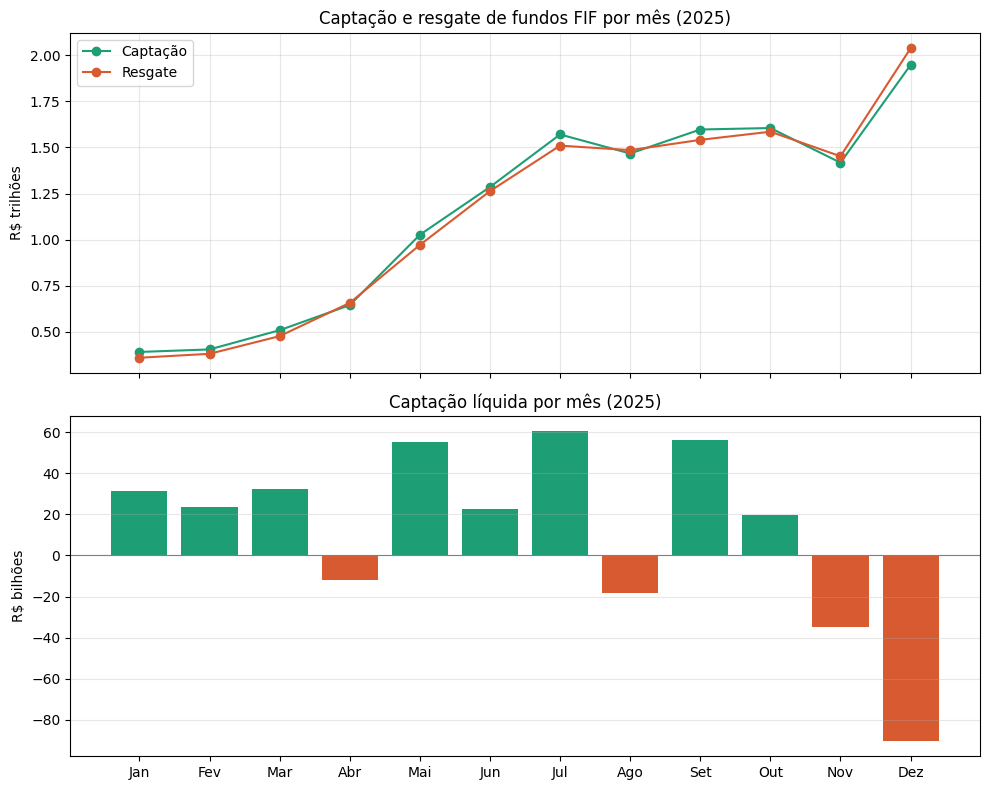

In [29]:
# grafico captação, resgate e captação líquida por mês em 2025 


import matplotlib.pyplot as plt

df_p2b = con.execute("""
    SELECT
        EXTRACT(MONTH FROM i.dt_comptc) AS mes,
        SUM(i.captc_dia)              AS captacao_total,
        SUM(i.resg_dia)               AS resgate_total,
        SUM(i.captc_dia - i.resg_dia) AS captacao_liquida
    FROM informe_diario i
    JOIN classe c ON i.cnpj_classe = c.cnpj_classe
    WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
    GROUP BY mes
    ORDER BY mes
""").fetchdf()

meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico superior: captação vs resgate (em trilhões)
ax1.plot(meses_nomes, df_p2b['captacao_total'] / 1e12, marker='o', color='#1D9E75', label='Captação')
ax1.plot(meses_nomes, df_p2b['resgate_total'] / 1e12, marker='o', color='#D85A30', label='Resgate')
ax1.set_ylabel('R$ trilhões')
ax1.set_title('Captação e resgate de fundos FIF por mês (2025)')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico inferior: captação líquida (com cor condicional positivo/negativo)
cores = ['#1D9E75' if v >= 0 else '#D85A30' for v in df_p2b['captacao_liquida']]
ax2.bar(meses_nomes, df_p2b['captacao_liquida'] / 1e9, color=cores)
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.set_ylabel('R$ bilhões')
ax2.set_title('Captação líquida por mês (2025)')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../docs/grafico_p2_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# pergunta 3: quais administradores concentram maior patrimônio entre os fundos FIF ativos em 2025?

con.execute("""
    WITH pl_admin AS (
        SELECT
            a.nome AS administrador,
            SUM(c.patrimonio_liquido) AS patrimonio_total
        FROM classe c
        JOIN fundo f ON c.id_registro_fundo = f.id_registro_fundo
        JOIN administrador a ON f.cnpj_administrador = a.cnpj_administrador
        WHERE c.situacao = 'Em Funcionamento Normal'
          AND c.tipo_classe = 'Classes de Cotas de Fundos FIF'
        GROUP BY a.nome
    )
    SELECT
        administrador,
        patrimonio_total,
        ROUND(100.0 * patrimonio_total / SUM(patrimonio_total) OVER (), 2) AS pct_mercado,
        ROUND(100.0 * SUM(patrimonio_total) OVER (
            ORDER BY patrimonio_total DESC
        ) / SUM(patrimonio_total) OVER (), 2) AS pct_acumulado
    FROM pl_admin
    ORDER BY patrimonio_total DESC
    LIMIT 15
""").fetchdf()

,administrador,patrimonio_total,pct_mercado,pct_acumulado
0,BB GESTAO DE RECURSOS DTVM S.A,3.310379e+12,23.90,23.90
1,ITAU UNIBANCO S.A.,2.111566e+12,15.24,39.14
2,BANCO BRADESCO S.A.,1.495252e+12,10.79,49.93
3,CAIXA ECONOMICA FEDERAL,1.211372e+12,8.74,58.68
4,BTG PACTUAL SERVIÇOS FINANCEIROS S/A DTVM,1.094105e+12,7.90,66.58
5,INTRAG DTVM LTDA.,8.481482e+11,6.12,72.70
6,BEM - DISTRIBUIDORA DE TITULOS E VALORES MOBIL...,6.631931e+11,4.79,77.49
7,SANTANDER DISTRIBUIDORA DE TÍTULOS E VALORES M...,6.545750e+11,4.73,82.21
8,BNY MELLON SERVICOS FINANCEIROS DTVM S.A.,6.274622e+11,4.53,86.74
9,SAFRA ASSET CORRETORA DE TÍTULOS E VALORES MOB...,2.822876e+11,2.04,88.78


C:\Users\Natalia\AppData\Local\Temp\ipykernel_14444\759412683.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_p3['admin_curto'], rotation=45, ha='right', fontsize=9)


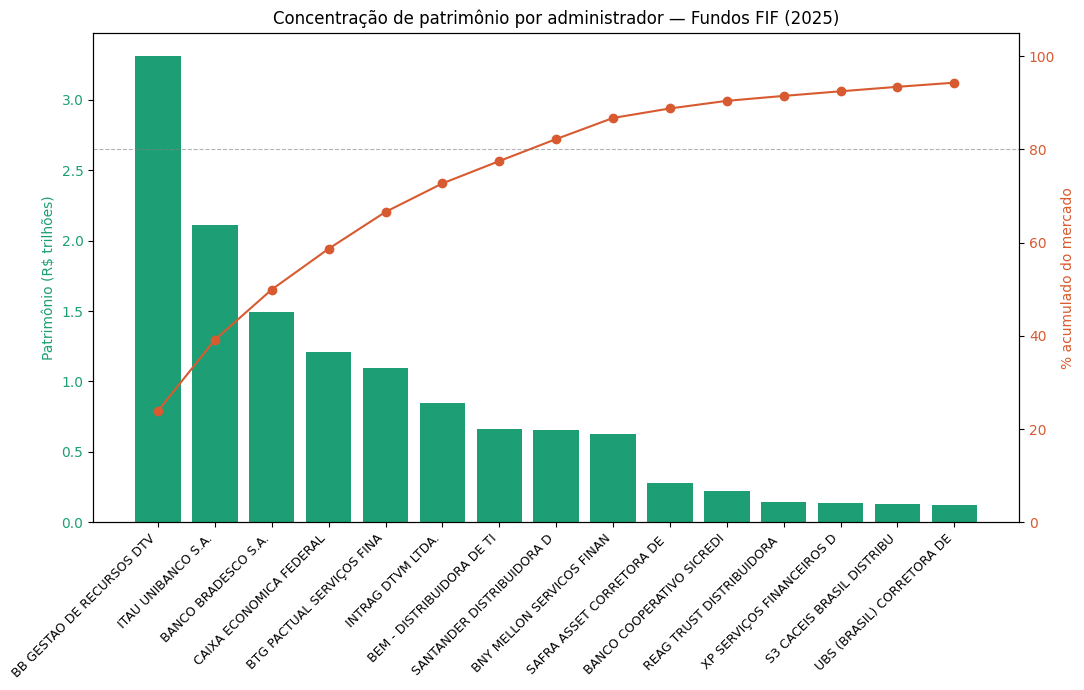

In [31]:
# gráfico concentração de patrimônio por administrador

import matplotlib.pyplot as plt

df_p3 = con.execute("""
    WITH pl_admin AS (
        SELECT
            a.nome AS administrador,
            SUM(c.patrimonio_liquido) AS patrimonio_total
        FROM classe c
        JOIN fundo f ON c.id_registro_fundo = f.id_registro_fundo
        JOIN administrador a ON f.cnpj_administrador = a.cnpj_administrador
        WHERE c.situacao = 'Em Funcionamento Normal'
          AND c.tipo_classe = 'Classes de Cotas de Fundos FIF'
        GROUP BY a.nome
    )
    SELECT
        administrador,
        patrimonio_total,
        ROUND(100.0 * patrimonio_total / SUM(patrimonio_total) OVER (), 2) AS pct_mercado,
        ROUND(100.0 * SUM(patrimonio_total) OVER (
            ORDER BY patrimonio_total DESC
        ) / SUM(patrimonio_total) OVER (), 2) AS pct_acumulado
    FROM pl_admin
    ORDER BY patrimonio_total DESC
    LIMIT 15
""").fetchdf()

# Encurta nomes longos para caber no eixo
df_p3['admin_curto'] = df_p3['administrador'].str.slice(0, 25)

fig, ax1 = plt.subplots(figsize=(11, 7))

ax1.bar(df_p3['admin_curto'], df_p3['patrimonio_total'] / 1e12, color='#1D9E75')
ax1.set_ylabel('Patrimônio (R$ trilhões)', color='#1D9E75')
ax1.tick_params(axis='y', labelcolor='#1D9E75')
ax1.set_xticklabels(df_p3['admin_curto'], rotation=45, ha='right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(df_p3['admin_curto'], df_p3['pct_acumulado'], color='#D85A30', marker='o')
ax2.set_ylabel('% acumulado do mercado', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.set_ylim(0, 105)
ax2.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax1.set_title('Concentração de patrimônio por administrador — Fundos FIF (2025)')

plt.tight_layout()
plt.savefig('../docs/grafico_p3_concentracao_admin.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# pergunta 4: qual classificação ANBIMA apresenta maior volatilidade no valor da cota?

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    retornos AS (
        SELECT
            i.cnpj_classe,
            i.id_subclasse,
            c.classificacao_anbima,
            i.vl_quota / LAG(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) - 1 AS retorno_diario
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
          AND c.classificacao_anbima IS NOT NULL
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT
        classificacao_anbima,
        COUNT(DISTINCT cnpj_classe)              AS qtd_classes,
        ROUND(STDDEV(retorno_diario) * 100, 4)   AS volatilidade_pct
    FROM retornos
    WHERE retorno_diario IS NOT NULL
    GROUP BY classificacao_anbima
    HAVING COUNT(DISTINCT cnpj_classe) >= 100
    ORDER BY volatilidade_pct DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,volatilidade_pct
0,Multimercados Livre,3801,1.723494e+07
1,Ações Livre,1978,1.677830e+07
2,Multimercados Invest. no Exterior,4988,1.022197e+07
3,Renda Fixa Simples,163,5.760456e+02
4,Ações Invest. no Exterior,1094,3.508934e+02
5,Multimercados Estrat. Específica,366,7.850800e+00
6,Fechados de Ações,129,2.068900e+00
7,Renda Fixa Duração Livre Crédito Livre,2685,1.845000e+00
8,Ações Valor/Crescimento,104,1.129600e+00
9,Previdência Ações Ativo,281,1.059000e+00


In [33]:
# retornos diários mais extremos em Multimercados Livre, Ações Livre

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    retornos AS (
        SELECT
            i.cnpj_classe,
            c.denominacao_social,
            c.classificacao_anbima,
            i.dt_comptc,
            i.vl_quota,
            LAG(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) AS vl_quota_anterior
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.classificacao_anbima IN ('Multimercados Livre', 'Ações Livre', 'Multimercados Invest. no Exterior')
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT *,
        ROUND((vl_quota / vl_quota_anterior - 1) * 100, 2) AS retorno_diario_pct
    FROM retornos
    WHERE vl_quota_anterior IS NOT NULL AND vl_quota_anterior > 0
    ORDER BY ABS(vl_quota / vl_quota_anterior - 1) DESC
    LIMIT 10
""").fetchdf()

,cnpj_classe,denominacao_social,classificacao_anbima,dt_comptc,vl_quota,vl_quota_anterior,retorno_diario_pct
0,32.287.638/0001-41,ARAIAN FUNDO DE INVESTIMENTO NO EXTERIOR MULTI...,Multimercados Invest. no Exterior,2025-11-06,1.492329e+08,1.489068,1.002190e+10
1,54.501.062/0001-06,BRS INVEST REALTY AND ASSETS' FUNDO DE INVESTI...,Multimercados Livre,2025-11-06,1.199936e+08,1.199936,1.000000e+10
2,27.591.034/0001-54,SINGULAR PLUS FUNDO DE INVESTIMENTO MULTIMERCA...,Multimercados Livre,2025-11-06,5.606203e+07,0.560627,9.999879e+09
3,41.251.230/0001-00,ARENA VALOR FUNDO DE INVESTIMENTO EM AÇÕES,Ações Livre,2025-11-06,1.223542e+08,1.230210,9.945796e+09
4,43.121.053/0001-73,HEKTOR FUNDO DE INVESTIMENTO MULTIMERCADO CRÉD...,Multimercados Invest. no Exterior,2025-11-06,7.302212e+08,73.005673,1.000225e+09
5,54.505.100/0001-07,ARLES FUNDO DE INVESTIMENTO MULTIMERCADO - CRÉ...,Multimercados Livre,2025-02-19,7.039372e+06,1064.440196,6.612215e+05
6,58.570.048/0001-15,FIEMP FUNDO DE INVESTIMENTO MULTIMERCADO CRÉDI...,Multimercados Livre,2025-10-22,9.555123e+02,0.812153,1.175518e+05
7,59.376.901/0001-25,INVISTA REAL ESTATE US PRIV CREDIT FUNDO DE IN...,Multimercados Livre,2025-07-11,1.003531e+03,0.955394,1.049385e+05
8,54.253.330/0001-18,AZIMUT AUTOMOBILE HERITAGE ENHANCEMENT FUNDO D...,Multimercados Invest. no Exterior,2025-07-15,1.004173e+03,0.959498,1.045561e+05
9,62.132.937/0001-78,BUSINESS ONE FUNDO DE INVESTIMENTO MULTIMERCAD...,Multimercados Livre,2025-11-07,1.008119e+03,1.005000,1.002103e+05


In [34]:
# quantos saltos de retorno diário extremo existem,
# confirmar se estão concentrados em 2025-11-06

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    retornos AS (
        SELECT
            i.cnpj_classe,
            i.dt_comptc,
            i.vl_quota / LAG(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) - 1 AS retorno_diario
        FROM informe_diario i
        WHERE i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT dt_comptc, COUNT(*) AS qtd_saltos_extremos
    FROM retornos
    WHERE ABS(retorno_diario) > 10
    GROUP BY dt_comptc
    ORDER BY qtd_saltos_extremos DESC
    LIMIT 10
""").fetchdf()

,dt_comptc,qtd_saltos_extremos
0,2025-11-07,14
1,2025-09-01,6
2,2025-11-06,5
3,2025-07-11,2
4,2025-08-25,2
5,2025-08-08,2
6,2025-04-04,1
7,2025-03-14,1
8,2025-06-16,1
9,2025-06-09,1


In [35]:
# pergunta 4: exclui retornos diários extremos 

con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    retornos AS (
        SELECT
            i.cnpj_classe,
            i.id_subclasse,
            c.classificacao_anbima,
            i.vl_quota / LAG(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) - 1 AS retorno_diario
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
          AND c.classificacao_anbima IS NOT NULL
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT
        classificacao_anbima,
        COUNT(DISTINCT cnpj_classe)              AS qtd_classes,
        ROUND(STDDEV(retorno_diario) * 100, 4)   AS volatilidade_pct
    FROM retornos
    WHERE retorno_diario IS NOT NULL
      AND ABS(retorno_diario) <= 10
    GROUP BY classificacao_anbima
    HAVING COUNT(DISTINCT cnpj_classe) >= 100
    ORDER BY volatilidade_pct DESC
""").fetchdf()

,classificacao_anbima,qtd_classes,volatilidade_pct
0,Multimercados Estrat. Específica,366,6.7334
1,Multimercados Livre,3801,2.7084
2,Fechados de Ações,129,2.0689
3,Renda Fixa Duração Livre Crédito Livre,2685,1.8450
4,Ações Livre,1978,1.6846
5,Multimercados Invest. no Exterior,4988,1.5037
6,Ações Invest. no Exterior,1094,1.2828
7,Ações Valor/Crescimento,104,1.1296
8,Previdência Ações Ativo,281,1.0590
9,Ações Índice Ativo,194,0.9911


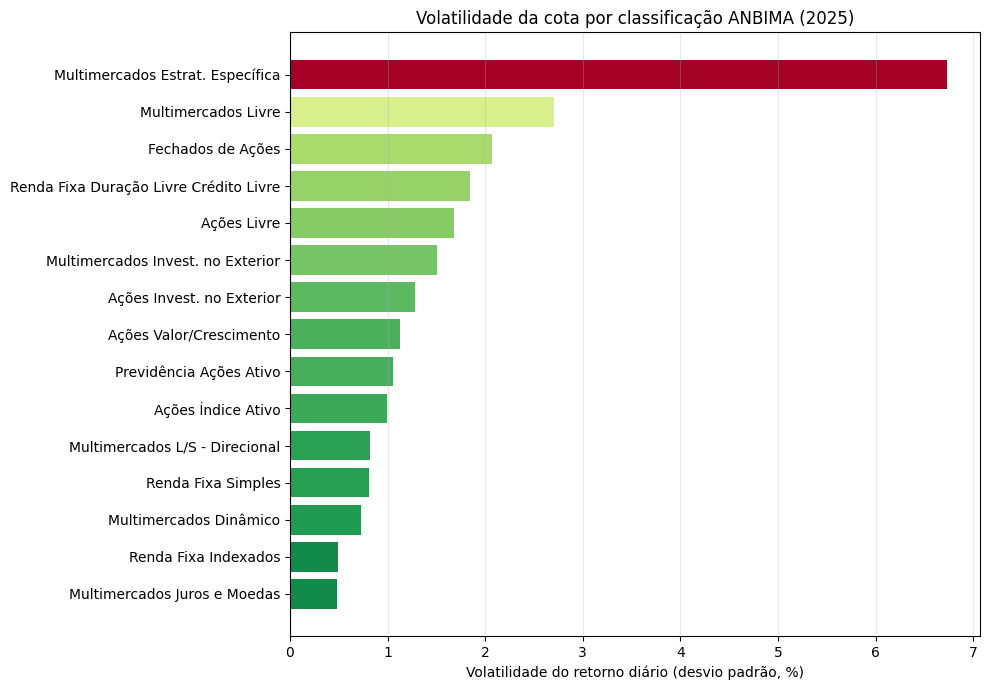

In [36]:
# gráfico: volatilidade do retorno diário por classificação ANBIMA (2025)

import matplotlib.pyplot as plt

df_p4 = con.execute("""
    WITH classes_invalidas AS (
        SELECT DISTINCT cnpj_classe
        FROM informe_diario
        WHERE vl_quota <= 0.01
    ),
    retornos AS (
        SELECT
            i.cnpj_classe,
            i.id_subclasse,
            c.classificacao_anbima,
            i.vl_quota / LAG(i.vl_quota) OVER (
                PARTITION BY i.cnpj_classe, i.id_subclasse
                ORDER BY i.dt_comptc
            ) - 1 AS retorno_diario
        FROM informe_diario i
        JOIN classe c ON i.cnpj_classe = c.cnpj_classe
        WHERE c.tipo_classe = 'Classes de Cotas de Fundos FIF'
          AND c.classificacao_anbima IS NOT NULL
          AND i.cnpj_classe NOT IN (SELECT cnpj_classe FROM classes_invalidas)
    )
    SELECT
        classificacao_anbima,
        COUNT(DISTINCT cnpj_classe)              AS qtd_classes,
        ROUND(STDDEV(retorno_diario) * 100, 4)   AS volatilidade_pct
    FROM retornos
    WHERE retorno_diario IS NOT NULL
      AND ABS(retorno_diario) <= 10
    GROUP BY classificacao_anbima
    HAVING COUNT(DISTINCT cnpj_classe) >= 100
    ORDER BY volatilidade_pct DESC
    LIMIT 15
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 7))

cores = plt.cm.RdYlGn_r(df_p4['volatilidade_pct'] / df_p4['volatilidade_pct'].max())

ax.barh(df_p4['classificacao_anbima'], df_p4['volatilidade_pct'], color=cores)
ax.invert_yaxis()
ax.set_xlabel('Volatilidade do retorno diário (desvio padrão, %)')
ax.set_title('Volatilidade da cota por classificação ANBIMA (2025)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/grafico_p4_volatilidade.png', dpi=150, bbox_inches='tight')
plt.show()